# Credibilistic Portfolio Optimisation — CTFN Fitting + MOGA
**Paper**: Mandal, Thakur & Mittal (2024), *Applied Soft Computing* 151, 111155

---
### Structure
1. Setup & load data
2. CTFN moment formulas (Eqs. 3–8)
3. Portfolio return + CTFN fitting (Section 4.1, Steps I–VI)
4. MOGA operators (Appendices B.1–B.4) + NSGA-II selection
5. K-medoids clustering (Appendix B.5)
6. Main optimisation loop (Algorithm 1)
7. Run all 3 models × 2 markets
8. Results & comparison

## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import json, os, time, warnings
from copy import deepcopy
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'Project', 'data')
if not os.path.isdir(DATA_DIR):
    DATA_DIR = os.path.join(os.getcwd(), 'data')

# ── Load returns and convert to decimal fractions (÷100) ────────────────────
# CSVs store percentage returns (e.g. 2.5 = 2.5%).
# The paper uses decimal fractions (e.g. 0.025 = 2.5%) so we divide by 100
# to match the paper's scale for b1/b2/b3/k and all moment values.
nse_train  = pd.read_csv(os.path.join(DATA_DIR, 'nse_train.csv'),  index_col=0, parse_dates=True) / 100
nyse_train = pd.read_csv(os.path.join(DATA_DIR, 'nyse_train.csv'), index_col=0, parse_dates=True) / 100
nse_test   = pd.read_csv(os.path.join(DATA_DIR, 'nse_test.csv'),   index_col=0, parse_dates=True) / 100
nyse_test  = pd.read_csv(os.path.join(DATA_DIR, 'nyse_test.csv'),  index_col=0, parse_dates=True) / 100

with open(os.path.join(DATA_DIR, 'nifty_stock_key.json'))  as f: nifty_key = json.load(f)
with open(os.path.join(DATA_DIR, 'djia_stock_key.json'))   as f: djia_key  = json.load(f)

print(f'NSE  train: {nse_train.shape}   test: {nse_test.shape}')
print(f'NYSE train: {nyse_train.shape}  test: {nyse_test.shape}')
print(f'Return scale check — NSE median monthly return: {nse_train.median().median():.4f}  (expect ~0.01–0.03)')

NSE  train: (72, 18)   test: (24, 18)
NYSE train: (72, 18)  test: (24, 18)
Return scale check — NSE median monthly return: 0.0022  (expect ~0.01–0.03)


## 2. CTFN Moment Formulas (Eqs. 3–8)

For a **Coherent Triangular Fuzzy Number** $\tilde{A} = (b_1,b_2,b_3)_k$:
- $\alpha = b_2 - b_1$,  $\beta = b_3 - b_2$
- Constants: $c_j = \prod_{i=1}^{j}\frac{1}{k+i}$,  $c'_j = \prod_{i=1}^{j}\frac{1}{1+(i-1)k+k} = \prod_{i=0}^{j-1}\frac{1}{1+ik}$

More precisely:
$$c_1=\frac{1}{k+1},\; c_2=\frac{1}{(k+1)(k+2)},\; c_3=\frac{1}{(k+1)(k+2)(k+3)},\; c_4=\frac{1}{(k+1)(k+2)(k+3)(k+4)}$$
$$c'_1=\frac{1}{1+k},\; c'_2=\frac{1}{(1+k)(1+2k)},\; c'_3=\frac{1}{(1+k)(1+2k)(1+3k)},\; c'_4=\frac{1}{(1+k)(1+2k)(1+3k)(1+4k)}$$

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: constant sequences
# ─────────────────────────────────────────────────────────────────────────────
def _c(k, j):   # c_j  = 1 / [(k+1)(k+2)...(k+j)]
    r = 1.0
    for i in range(1, j+1):
        r *= 1.0 / (k + i)
    return r

def _cp(k, j):  # c'_j = 1 / [(1+k)(1+2k)...(1+jk)]
    r = 1.0
    for i in range(1, j+1):
        r *= 1.0 / (1.0 + i * k)
    return r


# ─────────────────────────────────────────────────────────────────────────────
# Eq. 3  — Credibilistic Mean
# Paper: E[Ã] = b2 + (β − kα) / (2(k+1))
# ─────────────────────────────────────────────────────────────────────────────
def ctfn_mean(b1, b2, b3, k):
    α = b2 - b1
    β = b3 - b2
    return b2 + (β - k * α) / (2 * (k + 1))   # FIX: was b2 + 0.5*(β - k*α/(k+1))


# ─────────────────────────────────────────────────────────────────────────────
# Eq. 4  — Credibilistic Semivariance
# ─────────────────────────────────────────────────────────────────────────────
def ctfn_sv(b1, b2, b3, k, e=None):
    α = b2 - b1;  β = b3 - b2
    if e is None:
        e = ctfn_mean(b1, b2, b3, k)
    c1  = _c(k,1);  c2  = _c(k,2)
    cp2 = _cp(k,2)
    ρ2 = b2 - e
    ρ3 = b3 - e

    if e <= b2:                    # Case 1: b1 ≤ e ≤ b2  (β ≤ kα)
        ρ1 = e - b1
        return k**2 * (ρ1 ** (1/k + 2)) * cp2 / (α ** (1/k))
    else:                          # Case 2: b2 < e ≤ b3  (β > kα)
        Δ1 = -k*α*ρ2*c1 + k**2*α**2*cp2 + ρ2**2 + ρ2*β*c1 + β**2*c2
        return Δ1 - (ρ3 ** (k + 2)) * c2 / (β ** k)


# ─────────────────────────────────────────────────────────────────────────────
# Eq. 5  — Credibilistic MASD
# ─────────────────────────────────────────────────────────────────────────────
def ctfn_masd(b1, b2, b3, k):
    α = b2 - b1;  β = b3 - b2
    if k * α >= β:                 # Case kα ≥ β
        inner = 1 + (β - k*α) / (2*α*(k+1))
        return k*α / (2*(k+1)) * (inner ** ((k+1)/k))
    else:                          # Case kα ≤ β
        inner = 1 + (k*α - β) / (2*β*(k+1))
        return β / (2*(k+1)) * (inner ** (k+1))


# ─────────────────────────────────────────────────────────────────────────────
# Eq. 6  — Credibilistic CVaR
# ─────────────────────────────────────────────────────────────────────────────
def ctfn_cvar(b1, b2, b3, k, p=0.95):
    α = b2 - b1;  β = b3 - b2
    if p < 0.5:
        num = (2*p*(1 - (2*p)**k) + k*(2*p - 1)) * α + β
        return b2 + num / (2*(k+1)*(1-p))
    else:
        return (α + β - k*β*(2*(1-p))**(1/k)) / (k+1)


# ─────────────────────────────────────────────────────────────────────────────
# Eq. 7  — Credibilistic Skewness
# ─────────────────────────────────────────────────────────────────────────────
def ctfn_skewness(b1, b2, b3, k, e=None):
    """S[Ã] = ρ₂³ + (3/2)*(β·Ξ₁ − kα·Ξ₂)"""
    α = b2 - b1;  β = b3 - b2
    if e is None:
        e = ctfn_mean(b1, b2, b3, k)
    c1  = _c(k,1);  c2  = _c(k,2);  c3  = _c(k,3)
    cp1 = _cp(k,1); cp2 = _cp(k,2); cp3 = _cp(k,3)
    ρ2  = b2 - e
    Ξ1  = ρ2**2*c1  + 2*β*ρ2*c2   + 2*β**2*c3
    Ξ2  = ρ2**2*cp1 - 2*k*α*ρ2*cp2 + 2*k**2*α**2*cp3
    return ρ2**3 + 1.5*(β*Ξ1 - k*α*Ξ2)


# ─────────────────────────────────────────────────────────────────────────────
# Eq. 8  — Credibilistic Semikurtosis
# ─────────────────────────────────────────────────────────────────────────────
def ctfn_sk(b1, b2, b3, k, e=None):
    α = b2 - b1;  β = b3 - b2
    if e is None:
        e = ctfn_mean(b1, b2, b3, k)
    c1  = _c(k,1);  c2  = _c(k,2);  c3  = _c(k,3);  c4  = _c(k,4)
    cp1 = _cp(k,1); cp2 = _cp(k,2); cp3 = _cp(k,3); cp4 = _cp(k,4)
    ρ2  = b2 - e

    if e <= b2:                    # Case 1: b1 ≤ e ≤ b2
        ρ1 = e - b1
        return 12 * k**4 * (ρ1 ** (1/k + 4)) * cp4 / (α ** (1/k))   # FIX: was 0.5
    else:                          # Case 2: b2 < e ≤ b3
        ρ3  = b3 - e
        Ω1  = ρ2**3*c1  + 3*β*ρ2**2*c2  + 6*β**2*ρ2*c3  + 6*β**3*c4
        Ω2  = ρ2**3*cp1 - 3*k*α*ρ2**2*cp2 + 6*k**2*α**2*ρ2*cp3 - 6*k**3*α**3*cp4
        return 2*β*Ω1 - 2*k*α*Ω2 + ρ2**4 - 12*(ρ3**(k+4))*c4/(β**k)  # FIX: was 0.5


# ─────────────────────────────────────────────────────────────────────────────
# Sanity checks
# k=1 closed forms: E=(b1+2b2+b3)/4, S=(β+α)²(β−α)/32
# ─────────────────────────────────────────────────────────────────────────────
def _run_sanity_checks():
    b1, b2, b3, k = -0.05, 0.01, 0.15, 1.0
    α = b2-b1; β = b3-b2

    e_formula = ctfn_mean(b1, b2, b3, k)
    e_closed  = (b1 + 2*b2 + b3) / 4
    print(f'[k=1 Mean]     formula={e_formula:.6f}  closed={e_closed:.6f}  '
          f'match={abs(e_formula-e_closed)<1e-10}')

    s_formula = ctfn_skewness(b1, b2, b3, k)
    s_closed  = (β + α)**2 * (β - α) / 32
    print(f'[k=1 Skewness] formula={s_formula:.6e}  closed={s_closed:.6e}  '
          f'match={abs(s_formula-s_closed)<1e-12}')

_run_sanity_checks()

[k=1 Mean]     formula=0.030000  closed=0.030000  match=True
[k=1 Skewness] formula=1.000000e-04  closed=1.000000e-04  match=True


## 3. Portfolio Return + CTFN Fitting (Section 4.1)

Given a feasible portfolio $\mathbf{x}=(x_1,\ldots,x_n)$ with active asset indicators $z_i$:
$$R_t(\mathbf{x}) = 100\sum_{i=1}^n r_{ti}\,x_i\,z_i \qquad t=1,\ldots,T$$

Then fit $\tilde{A}_\mathbf{x}=(b_1,b_2,b_3)_k$ from the percentiles of $\{R_t\}$.

In [3]:
def portfolio_returns(weights, z, R_matrix):
    """Compute time-series of portfolio returns.
    weights : (n,) array of asset weights
    z       : (n,) binary array (1=active, 0=inactive)
    R_matrix: (T, n) array — individual asset returns (already ×100)
    Returns : (T,) array
    """
    return R_matrix @ (weights * z)


def fit_ctfn(port_rets, u=None, rng=None):
    """Steps I–VI of Section 4.1.
    port_rets : (T,) array of portfolio returns (%)
    u         : uniform random draw in [0,1]; if None, draw fresh
    Returns   : (b1, b2, b3, k)  — CTFN parameters
    """
    if rng is None: rng = np.random.default_rng()
    if u  is None: u = rng.uniform()

    pcts = np.percentile(port_rets, [3, 20, 50, 80, 97])
    Q3, Q20, Q50, Q80, Q97 = pcts

    b1 = min(port_rets.min(), Q3)   # Step IV  (Q3 = 3rd-percentile)
    b2 = Q50
    b3 = Q97

    # Protect against degenerate distributions
    EPS = 1e-12
    if b2 <= b1: b1 = b2 - EPS
    if b3 <= b2: b3 = b2 + EPS

    # Step V — shape parameter k
    if u < 0.5:
        denom = (b2 - Q20) / (b2 - b1)
    else:
        denom = (Q80 - b2) / (b3 - b2)

    denom = np.clip(denom, EPS, 1-EPS)   # guard log(0)
    k = np.log(0.5) / np.log(denom)
    k = np.clip(k, EPS, 100)             # k must be positive

    return b1, b2, b3, k


def compute_objectives(weights, z, R_matrix, p_cvar=0.95, u=None, rng=None):
    """Return the four objectives for a portfolio x=(weights, z).
    Objectives (in the paper's convention):
      f1 = E[Ã]       (maximise)
      f2 = risk       (minimise: SV or MASD or CVaR — caller specifies which)
      f3 = S[Ã]       (maximise)
      f4 = SK[Ã]      (minimise)
    Returns dict with all 6 moments so the caller can pick the right risk.
    """
    R = portfolio_returns(weights, z, R_matrix)
    b1, b2, b3, k = fit_ctfn(R, u=u, rng=rng)
    e = ctfn_mean(b1, b2, b3, k)
    return {
        'b1': b1, 'b2': b2, 'b3': b3, 'k': k,
        'mean':      e,
        'sv':        ctfn_sv(b1, b2, b3, k, e),
        'masd':      ctfn_masd(b1, b2, b3, k),
        'cvar':      ctfn_cvar(b1, b2, b3, k, p_cvar),
        'skewness':  ctfn_skewness(b1, b2, b3, k, e),
        'semikurt':  ctfn_sk(b1, b2, b3, k, e),
    }

print('CTFN fitting utilities ready.')

CTFN fitting utilities ready.


## 4. MOGA Operators

### 4a. Population representation

Each solution is stored as a 1-D array `x` of length `n` (total assets).  
Active assets have weight in `[l, u]`; inactive assets have weight `0`.

### 4b. Constraints
- Budget: $\sum x_i = 1$
- Cardinality: exactly $\kappa$ assets with $x_i > 0$
- Bounds: $l \le x_i \le u$ for active $i$

In [4]:
# ── Problem parameters (Table 3 of the paper) ────────────────────────────────
N          = 18      # total assets per market
KAPPA      = 5       # cardinality
L          = 0.08    # lower bound per active asset
U          = 0.30    # upper bound per active asset
P_CVAR     = 0.95    # CVaR confidence level
LAMBDA     = 1.0     # CCBEX shape parameter
P_MUT      = 5       # power-mutation index
K_MEDOIDS  = 25      # number of representative solutions
MIN_RETURN = 0.02    # 2% monthly return filter — returns now in decimal fractions

# ── MOGA hyperparameters ─────────────────────────────────────────────────────
POP_SIZE   = 180
G_MAX      = 2000
R_MAX      = 30


# ─────────────────────────────────────────────────────────────────────────────
# Repair mechanism  (Appendix B.4)
# ─────────────────────────────────────────────────────────────────────────────
def repair(x, l=L, u=U):
    x = x.copy()
    active = x > 0
    if not active.any():
        return x
    B = x[active].sum()
    if abs(B - 1.0) < 1e-10:
        return x
    elif B > 1.0:
        num = x[active] - l
        denom = num.sum()
        if denom < 1e-12:
            x[active] = 1.0 / active.sum()
        else:
            x[active] = l + num / denom * (1 - l * active.sum())
    else:
        num = u - x[active]
        denom = num.sum()
        if denom < 1e-12:
            x[active] = 1.0 / active.sum()
        else:
            x[active] = u - num / denom * (u * active.sum() - 1)
    return x


# ─────────────────────────────────────────────────────────────────────────────
# Population initialisation
# ─────────────────────────────────────────────────────────────────────────────
def init_population(pop_size=POP_SIZE, n=N, kappa=KAPPA, l=L, u=U, rng=None):
    if rng is None: rng = np.random.default_rng()
    pop = []
    while len(pop) < pop_size:
        x = np.zeros(n)
        active_idx = rng.choice(n, kappa, replace=False)
        weights = rng.uniform(l, u, kappa)
        x[active_idx] = weights
        x = repair(x, l, u)
        if abs(x.sum() - 1.0) < 1e-6 and (x[x > 0] >= l - 1e-9).all():
            pop.append(x)
    return np.array(pop)


# ─────────────────────────────────────────────────────────────────────────────
# CCBEX crossover  (Appendix B.1)
# ─────────────────────────────────────────────────────────────────────────────
def ccbex_crossover(x1, x2, l=L, u=U, lam=LAMBDA, rng=None):
    if rng is None: rng = np.random.default_rng()
    c1, c2 = x1.copy(), x2.copy()
    for i in range(len(x1)):
        if x1[i] > 0 and x2[i] > 0:
            if abs(x1[i] - x2[i]) < 1e-12:
                continue
            ri   = rng.uniform()
            diff = abs(x1[i] - x2[i])
            if ri <= 0.5:
                Cx1 = lam * np.log(abs(np.exp(-(x1[i]-l)/(lam*diff))
                                       + 2*ri*(1 - np.exp(-(x1[i]-l)/(lam*diff)))))
            else:
                Cx1 = -lam * np.log(abs(1 - (2*ri-1)*(1 - np.exp(-(u-x1[i])/(lam*diff)))))
            if ri <= 0.5:
                Cx2 = lam * np.log(abs(np.exp(-(x2[i]-l)/(lam*diff))
                                       + 2*ri*(1 - np.exp(-(x2[i]-l)/(lam*diff)))))
            else:
                Cx2 = -lam * np.log(abs(1 - (2*ri-1)*(1 - np.exp(-(u-x2[i])/(lam*diff)))))
            c1[i] = np.clip(x1[i] + Cx1 * diff, l, u)
            c2[i] = np.clip(x2[i] + Cx2 * diff, l, u)
    return c1, c2


# ─────────────────────────────────────────────────────────────────────────────
# Swap mutation  (Appendix B.2)
# ─────────────────────────────────────────────────────────────────────────────
def swap_mutation(x, l=L, u=U, rng=None):
    if rng is None: rng = np.random.default_rng()
    x = x.copy()
    active   = np.where(x > 0)[0]
    inactive = np.where(x == 0)[0]
    if len(active) == 0 or len(inactive) == 0:
        return x
    i = rng.choice(active)
    j = rng.choice(inactive)
    x[j] = l + (x[i] - l) / (u - l) * (u - l)
    x[i] = 0.0
    return x


# ─────────────────────────────────────────────────────────────────────────────
# Power mutation  (Appendix B.3)
# ─────────────────────────────────────────────────────────────────────────────
def power_mutation(x, l=L, u=U, p=P_MUT, rng=None):
    if rng is None: rng = np.random.default_rng()
    x = x.copy()
    active = np.where(x > 0)[0]
    if len(active) == 0:
        return x
    i  = rng.choice(active)
    ρi = rng.uniform()
    σi = rng.uniform()
    θi = (x[i] - l) / (u - l)
    χi = ρi ** (1.0 / p)
    if θi < σi:
        x[i] = x[i] - χi * (x[i] - l)
    else:
        x[i] = x[i] + χi * (u - x[i])
    x[i] = np.clip(x[i], l, u)
    return x


print(f'MOGA operators ready.  MIN_RETURN = {MIN_RETURN}  (decimal fraction = 2%)')

MOGA operators ready.  MIN_RETURN = 0.02  (decimal fraction = 2%)


## 5. NSGA-II Selection

In [5]:
def dominates(a, b):
    """Return True if objective-vector `a` dominates `b`.
    Convention: all objectives are to be MINIMISED.
    (Negate maximisation objectives before calling.)
    """
    return (np.all(a <= b)) and (np.any(a < b))


def fast_non_dominated_sort(obj):
    """NSGA-II non-dominated sort.
    obj : (pop, m) array, all objectives minimised.
    Returns list of fronts (each front = list of indices).
    """
    n   = len(obj)
    dom_count   = np.zeros(n, dtype=int)   # dominated by how many
    dom_set     = [[] for _ in range(n)]   # whom i dominates
    fronts      = [[]]

    for i in range(n):
        for j in range(n):
            if i == j: continue
            if dominates(obj[i], obj[j]):
                dom_set[i].append(j)
            elif dominates(obj[j], obj[i]):
                dom_count[i] += 1
        if dom_count[i] == 0:
            fronts[0].append(i)

    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in dom_set[i]:
                dom_count[j] -= 1
                if dom_count[j] == 0:
                    next_front.append(j)
        fronts.append(next_front)
        k += 1

    return fronts[:-1]  # remove empty last front


def crowding_distance(obj, front):
    """Compute crowding distance for members of `front`.
    obj   : (pop, m) — all objectives
    front : list of indices in this front
    Returns distances array of length len(front).
    """
    l = len(front)
    if l <= 2:
        return np.full(l, np.inf)
    dist = np.zeros(l)
    m    = obj.shape[1]
    for o in range(m):
        vals  = obj[front, o]
        order = np.argsort(vals)
        rng_o = vals[order[-1]] - vals[order[0]]
        if rng_o < 1e-12:
            continue
        dist[order[0]]  = np.inf
        dist[order[-1]] = np.inf
        for i in range(1, l-1):
            dist[order[i]] += (vals[order[i+1]] - vals[order[i-1]]) / rng_o
    return dist


def nsga2_select(pop, obj_combined, pop_size):
    """Select pop_size solutions from combined parent+offspring pool.
    pop         : (2*pop_size, n) solutions
    obj_combined: (2*pop_size, m) objectives (all minimised)
    Returns     : selected (pop_size, n) and (pop_size, m)
    """
    fronts  = fast_non_dominated_sort(obj_combined)
    chosen  = []
    for front in fronts:
        if len(chosen) + len(front) <= pop_size:
            chosen.extend(front)
        else:
            needed = pop_size - len(chosen)
            cd     = crowding_distance(obj_combined, front)
            order  = np.argsort(-cd)        # descending distance
            chosen.extend([front[i] for i in order[:needed]])
            break
    chosen = np.array(chosen[:pop_size])
    return pop[chosen], obj_combined[chosen]


print('NSGA-II selection ready.')

NSGA-II selection ready.


## 6. K-Medoids Clustering (Appendix B.5)

In [6]:
def kmedoids_representative(pareto_solutions, pareto_obj, k=K_MEDOIDS, rng=None):
    """Select K representative solutions from the Pareto-optimal set.

    Implements K-medoids via the KMeans-medoid approximation (BUILD phase):
      1. Fit KMeans (k clusters) on the weight vectors.
      2. For each centroid, pick the actual Pareto solution nearest to it.
    This avoids scikit-learn-extra (incompatible with NumPy 2.x) while
    preserving the paper's intent of diversity-aware representative selection.

    Returns (rep_solutions, rep_objectives).
    """
    m = len(pareto_solutions)
    if m <= k:
        return pareto_solutions, pareto_obj

    seed = int(rng.integers(1_000_000)) if rng is not None else 42
    km = KMeans(n_clusters=k, random_state=seed, n_init='auto', max_iter=500)
    km.fit(pareto_solutions)

    # For each centroid, find the nearest actual Pareto solution
    # (exclude already-chosen to avoid duplicates)
    chosen = []
    dists_to_centers = np.sum(
        (pareto_solutions[:, None, :] - km.cluster_centers_[None, :, :]) ** 2,
        axis=-1
    )   # shape (m, k)

    for ci in range(k):
        d = dists_to_centers[:, ci].copy()
        for already in chosen:
            d[already] = np.inf
        chosen.append(int(np.argmin(d)))

    chosen = np.array(chosen)
    return pareto_solutions[chosen], pareto_obj[chosen]


print('K-Medoids (KMeans-medoid approximation) ready.')

K-Medoids (KMeans-medoid approximation) ready.


## 7. Main Optimisation Loop (Algorithm 1)

### Model definitions
All three models share the same Maximise/Minimise structure:
- **Model I**: Maximise $E$, Minimise $SV$, Maximise $S$, Minimise $SK$
- **Model II**: Maximise $E$, Minimise $MASD$, Maximise $S$, Minimise $SK$
- **Model III**: Maximise $E$, Minimise $CVaR$, Maximise $S$, Minimise $SK$

For NSGA-II (minimisation convention), we negate $E$ and $S$.

In [7]:
RISK_KEY = {'I': 'sv', 'II': 'masd', 'III': 'cvar'}

def objectives_from_obs(obs, model):
    """Convert objectives dict → minimisation vector for NSGA-II.
    f = [-mean, risk, -skewness, semikurt]  — all minimised.
    """
    risk = RISK_KEY[model]
    return np.array([-obs['mean'], obs[risk], -obs['skewness'], obs['semikurt']])


def eval_population(pop, R_matrix, model, p_cvar=P_CVAR, u_fixed=None, rng=None):
    """Evaluate all solutions in the population.
    Returns (obj_matrix, raw_obs_list).
    """
    obj_list = []
    obs_list = []
    for x in pop:
        z  = (x > 0).astype(float)
        obs = compute_objectives(x, z, R_matrix, p_cvar=p_cvar,
                                  u=u_fixed, rng=rng)
        obj_list.append(objectives_from_obs(obs, model))
        obs_list.append(obs)
    return np.array(obj_list), obs_list


def run_moga(R_matrix, model, pop_size=POP_SIZE, g_max=G_MAX,
             n=N, kappa=KAPPA, l=L, u=U, lam=LAMBDA, p_mut=P_MUT,
             cp=0.7, mp=0.3, p_cvar=P_CVAR,
             verbose=True, seed=None):
    """Single MOGA run.  Returns Pareto-optimal (solutions, objectives)."""
    rng      = np.random.default_rng(seed)
    u_fixed  = rng.uniform()    # fix u for entire run (CTFN shape consistency)

    # Initialise population
    pop = init_population(pop_size, n, kappa, l, u, rng)
    obj, _ = eval_population(pop, R_matrix, model, p_cvar, u_fixed, rng)

    best_hv = -np.inf  # placeholder for progress tracking

    for g in range(g_max):
        offspring = []
        n_pop = len(pop)

        while len(offspring) < n_pop:
            # Tournament selection of parents
            i1, i2 = rng.integers(0, n_pop, 2)
            p1, p2  = pop[i1], pop[i2]

            # Crossover with probability cp
            if rng.uniform() < cp:
                c1, c2 = ccbex_crossover(p1, p2, l, u, lam, rng)
            else:
                c1, c2 = p1.copy(), p2.copy()

            # Swap mutation with probability mp
            if rng.uniform() < mp:
                c1 = swap_mutation(c1, l, u, rng)
            if rng.uniform() < mp:
                c2 = swap_mutation(c2, l, u, rng)

            # Power mutation with probability mp
            if rng.uniform() < mp:
                c1 = power_mutation(c1, l, u, p_mut, rng)
            if rng.uniform() < mp:
                c2 = power_mutation(c2, l, u, p_mut, rng)

            # Repair
            c1 = repair(c1, l, u)
            c2 = repair(c2, l, u)

            # Ensure cardinality after mutations
            for c in [c1, c2]:
                active_idx = np.where(c > 0)[0]
                if len(active_idx) != kappa:
                    continue   # discard malformed; naturally replaced
            offspring.extend([c1, c2])

        offspring = np.array(offspring[:n_pop])
        off_obj, _ = eval_population(offspring, R_matrix, model, p_cvar, u_fixed, rng)

        # Combine parent + offspring, NSGA-II select
        combined     = np.vstack([pop, offspring])
        combined_obj = np.vstack([obj, off_obj])
        pop, obj     = nsga2_select(combined, combined_obj, n_pop)

        if verbose and (g+1) % 200 == 0:
            fronts   = fast_non_dominated_sort(obj)
            n_pf     = len(fronts[0]) if fronts else 0
            print(f'  Gen {g+1:4d}/{g_max} | Pareto front size: {n_pf}')

    # Return Pareto front
    fronts   = fast_non_dominated_sort(obj)
    pf_idx   = fronts[0] if fronts else list(range(len(pop)))
    return pop[pf_idx], obj[pf_idx]


print('MOGA main loop ready.')

MOGA main loop ready.


## 8. Multi-Run Optimisation with Filtration

In [8]:
def optimise_model(R_matrix, model, r_max=R_MAX, pop_size=POP_SIZE, g_max=G_MAX,
                   cp=0.7, mp=0.3, min_return=MIN_RETURN, k_med=K_MEDOIDS,
                   verbose=True, base_seed=0):
    """
    Run R_MAX independent MOGA runs, pool Pareto solutions,
    apply filtration, then K-medoids clustering.

    Returns
    -------
    rep_sol : (k_med, n)   representative portfolio weight vectors
    rep_obj : (k_med, 4)   their objective values (minimisation convention)
    rep_raw : list[dict]   full observations (b1,b2,b3,k,mean,...) per rep solution
    all_pf  : (M, n)       all pooled Pareto solutions before clustering
    """
    rng       = np.random.default_rng(base_seed)
    all_sol   = []
    all_obj_l = []

    for run in range(r_max):
        seed_r = rng.integers(1_000_000)
        if verbose:
            print(f'[Model {model}]  Run {run+1}/{r_max}  (seed={seed_r})')
        pf_sol, pf_obj = run_moga(
            R_matrix, model,
            pop_size=pop_size, g_max=g_max,
            cp=cp, mp=mp, verbose=verbose,
            seed=int(seed_r)
        )
        all_sol.append(pf_sol)
        all_obj_l.append(pf_obj)

    all_sol = np.vstack(all_sol)
    all_obj = np.vstack(all_obj_l)

    # Re-extract Pareto front from pooled results
    fronts  = fast_non_dominated_sort(all_obj)
    pf_idx  = fronts[0] if fronts else list(range(len(all_sol)))
    pf_sol  = all_sol[pf_idx]
    pf_obj  = all_obj[pf_idx]

    if verbose:
        print(f'  Pooled Pareto front: {len(pf_sol)} solutions')

    # ── Filtration  (paper Section 5.1) ──────────────────────────────────────
    # Keep only solutions with mean ≥ min_return AND skewness ≥ 0
    # Objectives are [-mean, risk, -skew, sk] so:
    #   mean = -pf_obj[:,0]  skewness = -pf_obj[:,2]
    mask   = (-pf_obj[:, 0] >= min_return) & (-pf_obj[:, 2] >= 0)
    if mask.sum() == 0:
        print('  [Warning] No solutions passed filtration — relaxing to top-50% mean')
        threshold = np.percentile(-pf_obj[:, 0], 50)
        mask = (-pf_obj[:, 0] >= threshold) & (-pf_obj[:, 2] >= 0)
    if mask.sum() == 0:
        mask = np.ones(len(pf_sol), dtype=bool)  # fallback: keep all

    fs_sol = pf_sol[mask]
    fs_obj = pf_obj[mask]

    if verbose:
        print(f'  After filtration: {len(fs_sol)} solutions')

    # ── K-Medoids clustering ─────────────────────────────────────────────────
    rep_sol, rep_obj = kmedoids_representative(
        fs_sol, fs_obj, k=min(k_med, len(fs_sol)), rng=rng)

    # Compute full observations for representative solutions
    rep_raw = []
    u_fixed = rng.uniform()
    for x in rep_sol:
        z   = (x > 0).astype(float)
        obs = compute_objectives(x, z, R_matrix, u=u_fixed, rng=rng)
        rep_raw.append(obs)

    if verbose:
        print(f'  Representative solutions: {len(rep_sol)}')

    return rep_sol, rep_obj, rep_raw, pf_sol


print('Multi-run optimisation ready.')

Multi-run optimisation ready.


## 9. Quick Verification Run

Before the full R_max=30 run (which takes many hours), run a **quick smoke-test** with reduced parameters to verify the pipeline produces sensible results comparable to the paper's tables.

In [9]:
QUICK_TEST = True   # ← set False for full paper replication

if QUICK_TEST:
    QT_POP  = 60
    QT_GEN  = 200
    QT_RUNS = 3
    QT_KMED = 5
else:
    QT_POP  = POP_SIZE   # 180
    QT_GEN  = G_MAX      # 2000
    QT_RUNS = R_MAX      # 30
    QT_KMED = K_MEDOIDS  # 25

print(f'Mode: {"QUICK TEST" if QUICK_TEST else "FULL PAPER REPLICATION"}')
print(f'  pop={QT_POP}, gen={QT_GEN}, runs={QT_RUNS}, k_med={QT_KMED}')

Mode: QUICK TEST
  pop=60, gen=200, runs=3, k_med=5


In [10]:
# ── NSE — Model I  (Mean–SV–Skewness–Semikurtosis) ───────────────────────────
R_nse = nse_train.values   # (72, 18)

t0 = time.time()
nse_I_sol, nse_I_obj, nse_I_raw, nse_I_pf = optimise_model(
    R_nse, model='I',
    r_max=QT_RUNS, pop_size=QT_POP, g_max=QT_GEN,
    cp=0.7, mp=0.3,
    k_med=QT_KMED, verbose=True, base_seed=0
)
print(f'NSE Model I done in {(time.time()-t0)/60:.1f} min')

[Model I]  Run 1/3  (seed=850624)
  Gen  200/200 | Pareto front size: 60
[Model I]  Run 2/3  (seed=636961)
  Gen  200/200 | Pareto front size: 60
[Model I]  Run 3/3  (seed=511136)
  Gen  200/200 | Pareto front size: 60
  Pooled Pareto front: 124 solutions
  After filtration: 98 solutions
  Representative solutions: 5
NSE Model I done in 0.4 min


In [11]:
# ── Display NSE Model I results ───────────────────────────────────────────────
print('\nNSE — Model I — Representative Solutions')
print(f'{"Rep":<6} {"cp":>4} {"mp":>4}  {"b1":>9} {"b2":>9} {"b3":>9}  '
      f'{"k":>7}  {"Mean":>9} {"SV":>12} {"Skew":>12} {"SemiKurt":>12}')

stock_labels = list(nse_train.columns)   # S1..S18

for idx, (obs, sol) in enumerate(zip(nse_I_raw, nse_I_sol)):
    active = [stock_labels[i] for i in range(N) if sol[i] > 0]
    weights= [f'{sol[i]:.4f}' for i in range(N) if sol[i] > 0]
    print(f'R{idx+1:<5} {"":>4} {"":>4}  '
          f'{obs["b1"]:>9.5f} {obs["b2"]:>9.5f} {obs["b3"]:>9.5f}  '
          f'{obs["k"]:>7.4f}  '
          f'{obs["mean"]:>9.4e} {obs["sv"]:>12.4e} '
          f'{obs["skewness"]:>12.4e} {obs["semikurt"]:>12.4e}')
    print(f'  Active: {", ".join(f"{a}={w}" for a,w in zip(active,weights))}')


NSE — Model I — Representative Solutions
Rep      cp   mp         b1        b2        b3        k       Mean           SV         Skew     SemiKurt
R1                 -0.07544   0.01339   0.09913   0.7676  1.8352e-02   1.2416e-03   7.4460e-07   5.7451e-06
  Active: S5=0.1630, S8=0.2936, S11=0.1928, S17=0.0872, S18=0.2636
R2                 -0.07386   0.00361   0.12417   0.5284  2.9659e-02   1.5832e-03   5.9998e-05   7.3218e-06
  Active: S8=0.2983, S12=0.1465, S13=0.1244, S15=0.1330, S18=0.2978
R3                 -0.08332   0.00683   0.13663   0.6205  2.9618e-02   1.9175e-03   6.9692e-05   1.1492e-05
  Active: S1=0.1271, S8=0.2943, S13=0.1147, S15=0.1710, S18=0.2929
R4                 -0.10475   0.00773   0.14682   0.4475  3.8388e-02   2.4756e-03   7.1838e-05   1.9260e-05
  Active: S1=0.1498, S8=0.2897, S12=0.1959, S13=0.0820, S18=0.2826
R5                 -0.09492   0.01831   0.14167   0.7788  2.8200e-02   2.2494e-03   2.5875e-05   1.8082e-05
  Active: S8=0.2946, S12=0.1246, S16=0.198

In [12]:
# ── NSE — Model II  (Mean–MASD–Skewness–Semikurtosis) ────────────────────────
t0 = time.time()
nse_II_sol, nse_II_obj, nse_II_raw, nse_II_pf = optimise_model(
    R_nse, model='II',
    r_max=QT_RUNS, pop_size=QT_POP, g_max=QT_GEN,
    cp=0.7, mp=0.3,
    k_med=QT_KMED, verbose=False, base_seed=1
)
print(f'NSE Model II done in {(time.time()-t0)/60:.1f} min')

NSE Model II done in 0.4 min


In [13]:
# ── NSE — Model III  (Mean–CVaR–Skewness–Semikurtosis) ───────────────────────
t0 = time.time()
nse_III_sol, nse_III_obj, nse_III_raw, nse_III_pf = optimise_model(
    R_nse, model='III',
    r_max=QT_RUNS, pop_size=QT_POP, g_max=QT_GEN,
    cp=0.7, mp=0.3,
    k_med=QT_KMED, verbose=False, base_seed=2
)
print(f'NSE Model III done in {(time.time()-t0)/60:.1f} min')

NSE Model III done in 0.4 min


In [14]:
# ── NYSE — all three models ───────────────────────────────────────────────────
R_nyse = nyse_train.values  # (72, 18)

for mid, seed in zip(['I', 'II', 'III'], [3, 4, 5]):
    t0 = time.time()
    sol, obj, raw, pf = optimise_model(
        R_nyse, model=mid,
        r_max=QT_RUNS, pop_size=QT_POP, g_max=QT_GEN,
        cp=0.7, mp=0.3,
        k_med=QT_KMED, verbose=False, base_seed=seed
    )
    exec(f'nyse_{mid}_sol,nyse_{mid}_obj,nyse_{mid}_raw,nyse_{mid}_pf=sol,obj,raw,pf')
    print(f'NYSE Model {mid} done in {(time.time()-t0)/60:.1f} min')

NYSE Model I done in 0.4 min
NYSE Model II done in 0.4 min
NYSE Model III done in 0.4 min


## 10. Results Summary

In [15]:
import pandas as pd

def results_table(raw_list, model):
    risk_col = {'I':'sv', 'II':'masd', 'III':'cvar'}[model]
    risk_name = {'I':'SV', 'II':'MASD', 'III':'CVaR'}[model]
    rows = []
    for i, obs in enumerate(raw_list):
        rows.append({
            'Rep': f'R{i+1}',
            'b1':  round(obs['b1'], 5),
            'b2':  round(obs['b2'], 5),
            'b3':  round(obs['b3'], 5),
            'k':   round(obs['k'],  5),
            'Mean':  f"{obs['mean']:.3e}",
            risk_name: f"{obs[risk_col]:.3e}",
            'Skewness': f"{obs['skewness']:.3e}",
            'SemiKurt': f"{obs['semikurt']:.3e}",
        })
    return pd.DataFrame(rows).set_index('Rep')


print('=' * 70)
print('NSE — Model I   (training data)')
print('=' * 70)
display(results_table(nse_I_raw,   'I'))

print('\n' + '=' * 70)
print('NSE — Model II  (training data)')
print('=' * 70)
display(results_table(nse_II_raw,  'II'))

print('\n' + '=' * 70)
print('NSE — Model III (training data)')
print('=' * 70)
display(results_table(nse_III_raw, 'III'))

NSE — Model I   (training data)


,b1,b2,b3,k,Mean,SV,Skewness,SemiKurt
Rep,,,,,,,,
R1,-0.07544,0.01339,0.09913,0.76761,1.835e-02,1.242e-03,7.446e-07,5.745e-06
R2,-0.07386,0.00361,0.12417,0.52838,2.966e-02,1.583e-03,6.000e-05,7.322e-06
R3,-0.08332,0.00683,0.13663,0.62050,2.962e-02,1.917e-03,6.969e-05,1.149e-05
R4,-0.10475,0.00773,0.14682,0.44746,3.839e-02,2.476e-03,7.184e-05,1.926e-05
R5,-0.09492,0.01831,0.14167,0.77876,2.820e-02,2.249e-03,2.587e-05,1.808e-05



NSE — Model II  (training data)


,b1,b2,b3,k,Mean,MASD,Skewness,SemiKurt
Rep,,,,,,,,
R1,-0.07722,0.00415,0.12511,0.53553,2.935e-02,2.752e-02,5.855e-05,8.068e-06
R2,-0.08707,0.00456,0.13482,0.50773,3.233e-02,3.009e-02,7.019e-05,1.172e-05
R3,-0.07310,0.01119,0.09597,0.65152,2.023e-02,2.131e-02,5.565e-06,4.733e-06
R4,-0.07001,0.01055,0.11822,0.83020,2.169e-02,2.408e-02,3.316e-05,6.416e-06
R5,-0.07579,0.00642,0.12488,0.54650,3.019e-02,2.708e-02,5.346e-05,7.882e-06



NSE — Model III (training data)


,b1,b2,b3,k,Mean,CVaR,Skewness,SemiKurt
Rep,,,,,,,,
R1,-0.10498,0.00664,0.14759,0.65852,2.697e-02,1.506e-01,7.280e-05,2.122e-05
R2,-0.08447,0.01189,0.12973,0.59839,3.071e-02,1.331e-01,4.094e-05,1.095e-05
R3,-0.09039,0.01341,0.13517,0.52110,3.565e-02,1.478e-01,4.260e-05,1.319e-05
R4,-0.08914,0.00438,0.13521,0.66067,2.517e-02,1.335e-01,6.842e-05,1.263e-05
R5,-0.07782,0.00548,0.12990,0.66410,2.624e-02,1.233e-01,6.311e-05,9.021e-06


In [16]:
print('=' * 70)
print('NYSE — Model I   (training data)')
print('=' * 70)
display(results_table(nyse_I_raw,   'I'))

print('\n' + '=' * 70)
print('NYSE — Model II  (training data)')
print('=' * 70)
display(results_table(nyse_II_raw,  'II'))

print('\n' + '=' * 70)
print('NYSE — Model III (training data)')
print('=' * 70)
display(results_table(nyse_III_raw, 'III'))

NYSE — Model I   (training data)


,b1,b2,b3,k,Mean,SV,Skewness,SemiKurt
Rep,,,,,,,,
R1,-0.06905,0.01063,0.08890,0.85578,1.335e-02,1.028e-03,5.043e-07,3.885e-06
R2,-0.08024,0.01482,0.11452,0.52586,3.111e-02,1.468e-03,1.595e-05,7.609e-06
R3,-0.06734,0.01619,0.08840,0.87600,1.594e-02,1.027e-03,-7.201e-06,4.015e-06
R4,-0.07590,0.01145,0.09360,0.85898,1.337e-02,1.193e-03,-2.708e-06,5.306e-06
R5,-0.07833,0.01072,0.10655,0.60144,2.392e-02,1.344e-03,1.449e-05,6.409e-06



NYSE — Model II  (training data)


,b1,b2,b3,k,Mean,MASD,Skewness,SemiKurt
Rep,,,,,,,,
R1,-0.07674,0.01446,0.11045,0.56804,2.855e-02,2.386e-02,1.363e-05,6.671e-06
R2,-0.07214,0.01275,0.09714,0.60839,2.293e-02,2.134e-02,5.496e-06,4.678e-06
R3,-0.07927,0.01535,0.11490,0.52165,3.184e-02,2.483e-02,1.620e-05,7.486e-06
R4,-0.07204,0.01074,0.09160,0.97801,1.072e-02,2.045e-02,-1.353e-06,4.556e-06
R5,-0.07646,0.01335,0.09742,0.56664,2.394e-02,2.173e-02,2.397e-06,5.191e-06



NYSE — Model III (training data)


,b1,b2,b3,k,Mean,CVaR,Skewness,SemiKurt
Rep,,,,,,,,
R1,-0.07940,0.01528,0.11450,0.52098,3.168e-02,1.271e-01,1.576e-05,7.449e-06
R2,-0.08565,0.00724,0.09891,0.70397,1.495e-02,1.069e-01,4.330e-06,6.939e-06
R3,-0.08029,0.00686,0.08670,0.78641,1.002e-02,9.160e-02,-3.334e-06,4.992e-06
R4,-0.07893,0.01034,0.09935,0.60783,2.115e-02,1.101e-01,6.680e-06,5.745e-06
R5,-0.07860,0.01171,0.11028,0.61275,2.511e-02,1.162e-01,1.661e-05,6.978e-06


## 11. Out-of-Sample (Test) Evaluation

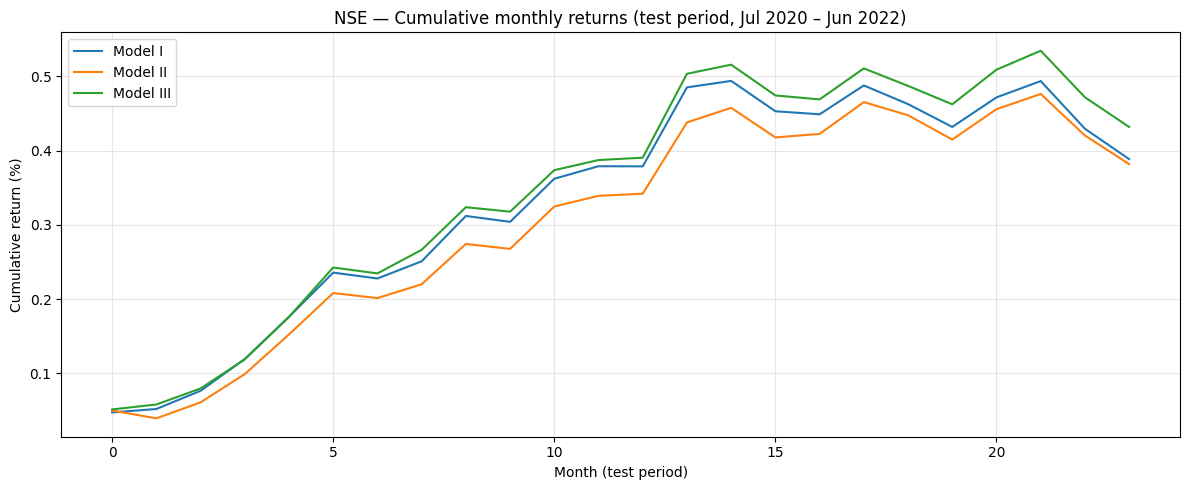

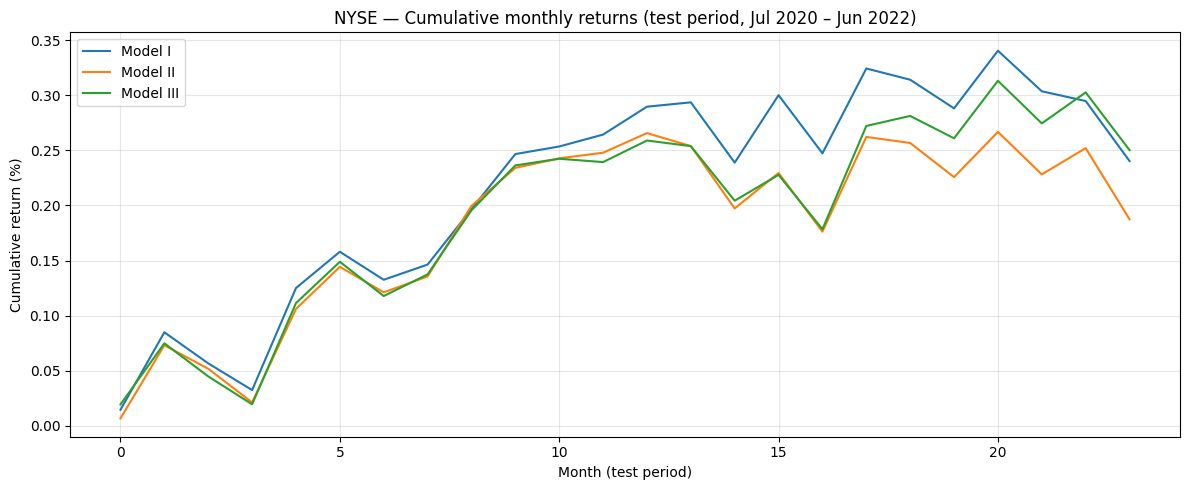

In [17]:
import matplotlib.pyplot as plt
import os
DATA_DIR_FIGS = os.path.join(os.getcwd(), 'data')

def cumulative_returns_plot(sol_dict, R_test, labels, title, fname=None):
    """Plot cumulative monthly returns on test data.
    sol_dict: {label: weight_matrix (k_med, n)}
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, sols in sol_dict.items():
        # Average cumulative return across representative portfolios
        cum_rets = []
        for x in sols:
            z = (x > 0).astype(float)
            ret = portfolio_returns(x, z, R_test)
            cum_rets.append(np.cumsum(ret))
        avg_cum = np.mean(cum_rets, axis=0)
        ax.plot(avg_cum, label=label)
    ax.set_title(title)
    ax.set_xlabel('Month (test period)')
    ax.set_ylabel('Cumulative return (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if fname:
        plt.savefig(os.path.join(DATA_DIR_FIGS, fname), dpi=150, bbox_inches='tight')
    plt.show()


# NSE test performance
cumulative_returns_plot(
    {'Model I': nse_I_sol, 'Model II': nse_II_sol, 'Model III': nse_III_sol},
    nse_test.values,
    labels=['Model I', 'Model II', 'Model III'],
    title='NSE — Cumulative monthly returns (test period, Jul 2020 – Jun 2022)',
    fname='nse_test_cumulative.png'
)

# NYSE test performance
cumulative_returns_plot(
    {'Model I': nyse_I_sol, 'Model II': nyse_II_sol, 'Model III': nyse_III_sol},
    nyse_test.values,
    labels=['Model I', 'Model II', 'Model III'],
    title='NYSE — Cumulative monthly returns (test period, Jul 2020 – Jun 2022)',
    fname='nyse_test_cumulative.png'
)

---
## Parameter Tuning Grid

The paper tries all combinations of `cp ∈ {0.6, 0.7, 0.8}` × `mp ∈ {0.2, 0.3, 0.4}` and picks the best.  
Run the cell below for the full grid search (warning: ~9× longer than a single run).

In [18]:
RUN_GRID_SEARCH = False   # ← set True to tune

if RUN_GRID_SEARCH:
    best_hv   = {}
    best_params = {}

    for market, R in [('NSE', R_nse), ('NYSE', R_nyse)]:
        for model in ['I', 'II', 'III']:
            key = f'{market}_{model}'
            best_hv[key] = -np.inf
            for cp in [0.6, 0.7, 0.8]:
                for mp in [0.2, 0.3, 0.4]:
                    sol, obj, raw, _ = optimise_model(
                        R, model=model,
                        r_max=3, pop_size=60, g_max=200,   # quick
                        cp=cp, mp=mp,
                        k_med=5, verbose=False, base_seed=99
                    )
                    # Use Pareto front size as proxy for quality
                    pf_size = len(obj)
                    print(f'{key}  cp={cp}  mp={mp}  PF={pf_size}')
                    if pf_size > best_hv[key]:
                        best_hv[key]     = pf_size
                        best_params[key] = (cp, mp)

    print('\nBest parameters:')
    for k, v in best_params.items():
        print(f'  {k}: cp={v[0]}, mp={v[1]}')